In [31]:
#import necessary packages
from pybaseball import playerid_lookup
from pybaseball import statcast_pitcher
from pybaseball import statcast_pitcher_spin
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from pybaseball import player_search_list
import random
import os
healthy_path = "./.data/healthy/"
injured_path = "./.data/injured/"
healthy = {}
injured = {}

In [32]:
#loading data into a dictionary for healthy players
def valuegen_healthy(file):
    data = pd.read_csv(file)
    name = data['player_name']# finding the player's name
    player_id = data.loc[0, 'pitcher']# finding the player id
    Fastballs = data.loc[data['pitch_type'].isin(['FF', 'SI'])]# creating data set of only fastballs
    FF = data.loc[data['pitch_type'].isin(['FF'])] # creating dataset of only four seam fastballs
    SI = data.loc[data['pitch_type'].isin(['SI'])] # creating dataset of only sinkers
    FC = data.loc[data['pitch_type'].isin(['FC'])] # creating dataset of only cutters
    OFF = data.loc[~data['pitch_type'].isin(['FF', 'SI'])] # creating a dataset of Offspeed pitches(not a fastball)
    CH = data.loc[data['pitch_type'].isin(['CH'])] # creating dataset of only changeups
    SPL = data.loc[data['pitch_type'].isin(['FS', 'FO'])] # creating dataset of only splitters
    SL = data.loc[data['pitch_type'].isin(['SL', 'SV', 'ST'])] # creating dataset of only sliders includng sweepers and slurves
    Sweep = data.loc[data['pitch_type'].isin(['ST'])] # creating dataset of only sweepers
    CU = data.loc[data['pitch_type'].isin(['CU', 'KC', 'CS'])] # creating a dateset of only curveballs including all variations
    mean_veloFF = FF['release_speed'].mean() # finding mean velocity of Fastballs
    mean_veloOFF = OFF['release_spin_rate'].mean() # finding mean velocity of Offspeed pitches
    mean_release = data['release_pos_z'].mean() # finding the mean release_pos_z
    mean_spinFF = FF['release_spin_rate'].mean() # finding the mean spin rate of fastballs
    mean_spinOFF = OFF['release_spin_rate'].mean() # finding the mean spin rate of offspeed pitches
    healthy[player_id] = [name, data, mean_veloFF, mean_veloOFF, mean_release, mean_spinFF, mean_spinOFF, Fastballs, FF, SI, FC, CH, SPL, SL, Sweep, CU, OFF]
    return data, mean_veloFF, mean_veloOFF, mean_release, mean_spinFF, mean_spinOFF

# populating the dictionary for healthy players
for filename in os.listdir(healthy_path):
    f = os.path.join(healthy_path, filename)
    # checking if it is a file
    if os.path.isfile(f):
        valuegen_healthy(healthy_path+filename)
# populating dictionary for injured players
def valuegen_injured(file):
    data = pd.read_csv(file)
    name = data['player_name']# finding the player's name
    player_id = data.loc[0, 'pitcher']# finding the player id
    Fastballs = data.loc[data['pitch_type'].isin(['FF', 'SI'])]# creating data set of only fastballs
    FF = data.loc[data['pitch_type'].isin(['FF'])] # creating dataset of only four seam fastballs
    SI = data.loc[data['pitch_type'].isin(['SI'])] # creating dataset of only sinkers
    FC = data.loc[data['pitch_type'].isin(['FC'])] # creating dataset of only cutters
    OFF = data.loc[~data['pitch_type'].isin(['FF', 'SI'])] # creating a dataset of Offspeed pitches(not a fastball)
    CH = data.loc[data['pitch_type'].isin(['CH'])] # creating dataset of only changeups
    SPL = data.loc[data['pitch_type'].isin(['FS', 'FO'])] # creating dataset of only splitters
    SL = data.loc[data['pitch_type'].isin(['SL', 'SV', 'ST'])] # creating dataset of only sliders includng sweepers and slurves
    Sweep = data.loc[data['pitch_type'].isin(['ST'])] # creating dataset of only sweepers
    CU = data.loc[data['pitch_type'].isin(['CU', 'KC', 'CS'])] # creating a dateset of only curveballs including all variations
    mean_veloFF = FF['release_speed'].mean() # finding mean velocity of Fastballs
    mean_veloOFF = OFF['release_spin_rate'].mean() # finding mean velocity of Offspeed pitches
    mean_release = data['release_pos_z'].mean() # finding the mean release_pos_z
    mean_spinFF = FF['release_spin_rate'].mean() # finding the mean spin rate of fastballs
    mean_spinOFF = OFF['release_spin_rate'].mean() # finding the mean spin rate of offspeed pitches
    injured[player_id] = [name, data, mean_veloFF, mean_veloOFF, mean_release, mean_spinFF, mean_spinOFF, Fastballs, FF, SI, FC, CH, SPL, SL, Sweep, CU, OFF]
    return data, mean_veloFF, mean_veloOFF, mean_release, mean_spinFF, mean_spinOFF

# populating injured dictionary
for filename in os.listdir(injured_path):
    f = os.path.join(injured_path, filename)
    # checking if it is a file
    if os.path.isfile(f):
        valuegen_injured(injured_path+filename)

print(len(healthy))

print(len(injured))

180
216


In [33]:
# creating a new dataset concatenating all healthy dataframes into one dataframe
healthy_data = [] # creating array that will hold each dataframe
for key in healthy.keys(): # iterating through the dictionary
  x = healthy[key][1] # getting the dataframe containing all the pitcher's data
  y = [] # creating an array that will hold the value of the 
  for i in x.values: # adding a zero for every row of data
    y.append(0)
  z = x.assign(TJ = y) # assign the y values to a new column called TJ
  healthy_data.append(z)# append to the healthy_data array
# creating a new dataset concatenating all healthy dataframes into one dataframe
injured_data = [] # creating array that will hold each dataframe
for key in injured.keys():# iterating through the dictionary
  x = injured[key][1] # getting the dataframe containing all the pitcher's data
  y = [] # creating an array that will hold the value of the 
  for i in x.values: # adding a one for every row of data
    y.append(1)
  z = x.assign(TJ = y)# assign the y values to a new column called TJ
  injured_data.append(z) # append to the healthy_data array
Healthy_df = pd.concat(healthy_data) # Concatenate all the data into one dataframe
Injured_df = pd.concat(injured_data) # Concatenate all the data into one dataframe

In [34]:
#Check the dataframe
Healthy_df.head()

,Unnamed: 0,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,...,n_priorpa_thisgame_player_at_bat,pitcher_days_since_prev_game,batter_days_since_prev_game,pitcher_days_until_next_game,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,TJ
0,0,SI,2023-10-04,94.3,-1.93,5.46,"Armstrong, Shawn",665750,542888,field_out,...,3,4.0,1.0,NaN,3.0,1.69,1.24,-1.24,35.0,0
1,1,SL,2023-10-04,84.2,-1.70,5.80,"Armstrong, Shawn",665750,542888,NaN,...,3,4.0,1.0,NaN,3.0,3.57,-0.95,0.95,41.0,0
2,2,FC,2023-10-04,91.8,-1.77,5.69,"Armstrong, Shawn",665750,542888,NaN,...,3,4.0,1.0,NaN,3.0,1.54,-0.32,0.32,43.0,0
3,3,SL,2023-10-04,84.7,-1.73,5.74,"Armstrong, Shawn",665750,542888,NaN,...,3,4.0,1.0,NaN,3.0,3.34,-1.13,1.13,40.9,0
4,4,SI,2023-10-04,95.3,-2.01,5.39,"Armstrong, Shawn",665750,542888,NaN,...,3,4.0,1.0,NaN,3.0,1.83,1.67,-1.67,36.2,0


In [35]:
#Check the dataframe
Injured_df.head()

,Unnamed: 0,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,...,n_priorpa_thisgame_player_at_bat,pitcher_days_since_prev_game,batter_days_since_prev_game,pitcher_days_until_next_game,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,TJ
0,0,FF,2016-10-02,93.1,0.31,6.25,"O'Rourke, Ryan",594809,594951,walk,...,3,2.0,1.0,NaN,NaN,1.71,0.13,0.13,NaN,1
1,1,SL,2016-10-02,80.7,0.52,6.38,"O'Rourke, Ryan",594809,594951,NaN,...,3,2.0,1.0,NaN,NaN,3.94,-0.69,-0.69,NaN,1
2,2,SL,2016-10-02,82.2,0.78,6.21,"O'Rourke, Ryan",594809,594951,NaN,...,3,2.0,1.0,NaN,NaN,2.91,-0.56,-0.56,NaN,1
3,3,CH,2016-10-02,83.6,0.40,6.35,"O'Rourke, Ryan",594809,594951,NaN,...,3,2.0,1.0,NaN,NaN,3.14,0.91,0.91,NaN,1
4,4,SL,2016-10-02,80.3,0.42,6.26,"O'Rourke, Ryan",594809,594951,NaN,...,3,2.0,1.0,NaN,NaN,3.65,-0.62,-0.62,NaN,1


In [36]:
# Check data lengths
Healthy_df.shape

(187907, 115)

In [37]:
Injured_df.shape

(239716, 115)

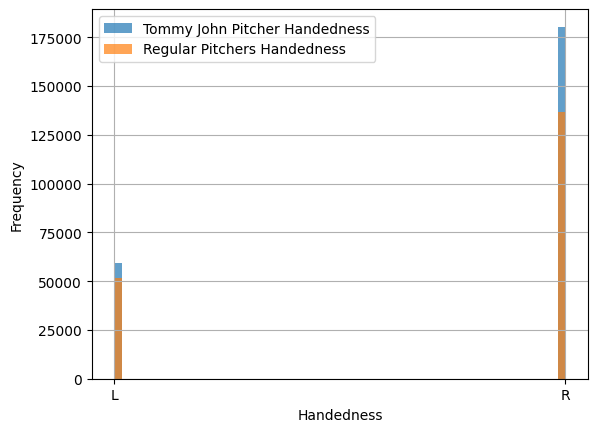

In [38]:
# create plot to see the pitcher handedness
plt.plot()
Injured_df['p_throws'].hist(bins = 60, alpha = 0.7, label = 'Tommy John Pitcher Handedness')
Healthy_df['p_throws'].hist(bins = 60, alpha = 0.7, label = 'Regular Pitchers Handedness')
plt.xlabel("Handedness")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/Pitcher_Handedness_Hist.png', dpi = 400)
plt.show()

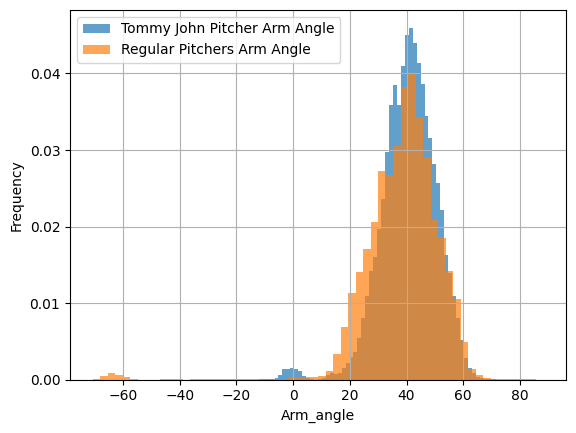

In [39]:
# plot to see arm angle
plt.plot()
Injured_df['arm_angle'].hist(bins = 60, alpha = 0.7, label = 'Tommy John Pitcher Arm Angle', density = True)
Healthy_df['arm_angle'].hist(bins = 60, alpha = 0.7, label = 'Regular Pitchers Arm Angle', density = True)
plt.xlabel("Arm_angle")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/Arm_Angle_Hist.png', dpi = 400)
plt.show()

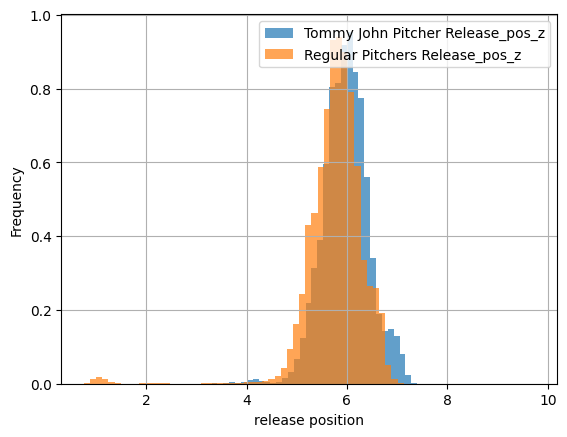

In [40]:
# plot to see release_pos_z
plt.plot()
Injured_df['release_pos_z'].hist(bins = 60, alpha = 0.7, label = 'Tommy John Pitcher Release_pos_z', density = True)
Healthy_df['release_pos_z'].hist(bins = 60, alpha = 0.7, label = 'Regular Pitchers Release_pos_z', density = True)
plt.xlabel("release position")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/Release_Pos_Z_Hist.png', dpi = 400)
plt.show()

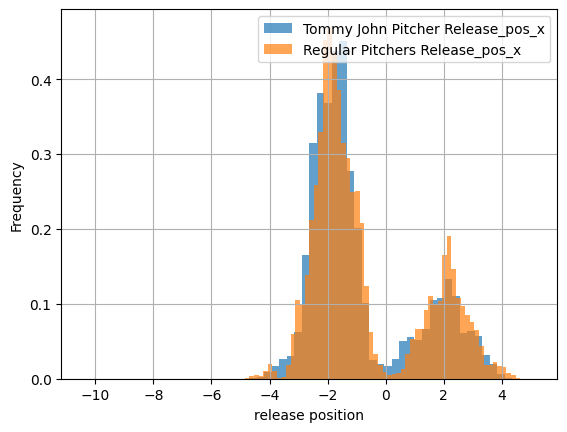

In [41]:
# plot to see release_pos_x
plt.plot()
Injured_df['release_pos_x'].hist(bins = 60, alpha = 0.7, label = 'Tommy John Pitcher Release_pos_x', density = True)
Healthy_df['release_pos_x'].hist(bins = 60, alpha = 0.7, label = 'Regular Pitchers Release_pos_x', density = True)
plt.xlabel("release position")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/Release_Pos_X_Hist.png', dpi = 400)
plt.show()

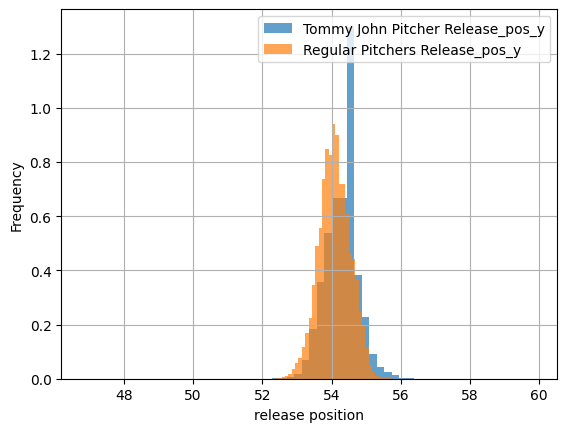

In [42]:
# plot to see release_pos_y
plt.plot()
Injured_df['release_pos_y'].hist(bins = 60, alpha = 0.7, label = 'Tommy John Pitcher Release_pos_y', density = True)
Healthy_df['release_pos_y'].hist(bins = 60, alpha = 0.7, label = 'Regular Pitchers Release_pos_y', density = True)
plt.xlabel("release position")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/Release_Pos_Y_Hist.png', dpi = 400)
plt.show()

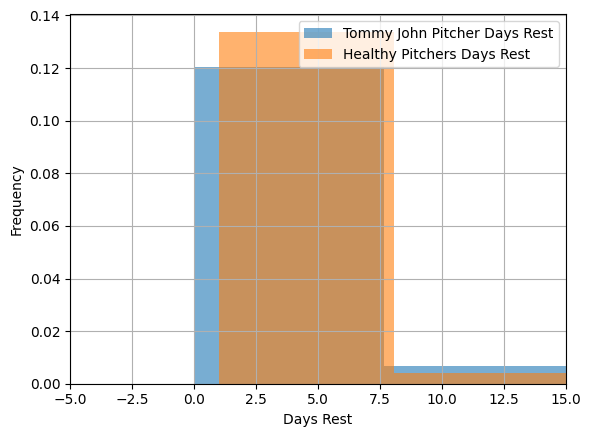

In [43]:
# plot to see days of rest
plt.plot()
Injured_df['pitcher_days_since_prev_game'].hist(bins = 20, alpha = 0.6, label = 'Tommy John Pitcher Days Rest', density = True)
Healthy_df['pitcher_days_since_prev_game'].hist(bins = 20, alpha = 0.6, label = 'Healthy Pitchers Days Rest', density = True)
plt.xlim(-5, 15)
plt.xlabel("Days Rest")
plt.ylabel("Frequency")
plt.savefig('.data/plots/Days_Of_Rest_Hist.png', dpi = 400)
plt.legend()
plt.show()

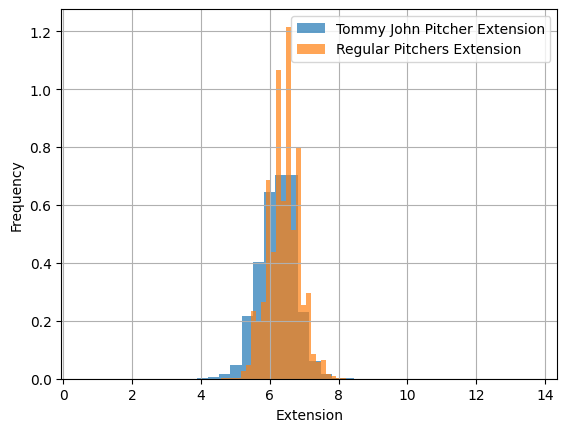

In [44]:
# Plot to see the release extension of pitchers
plt.plot()
Injured_df['release_extension'].hist(bins = 40, alpha = 0.7, label = 'Tommy John Pitcher Extension', density = True)
Healthy_df['release_extension'].hist(bins = 40, alpha = 0.7, label = 'Regular Pitchers Extension', density = True)
plt.xlabel("Extension")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/Release_Extension_Hist.png', dpi = 400)
plt.show()

In [45]:
# creating a dataframe of only fastballs
healthy_Fastball_data = []
for key in healthy.keys():
  x = healthy[key][7]
  y = []
  for i in x.values:
    y.append(0)
  z = x.assign(TJ = y)
  healthy_Fastball_data.append(z)
injured_Fastball_data = []
for key in injured.keys():
  x = injured[key][7]
  y = []
  for i in x.values:
    y.append(1)
  z = x.assign(TJ = y)
  injured_Fastball_data.append(z)
Healthy_Fastball_df = pd.concat(healthy_Fastball_data)
Injured_Fastball_df = pd.concat(injured_Fastball_data)

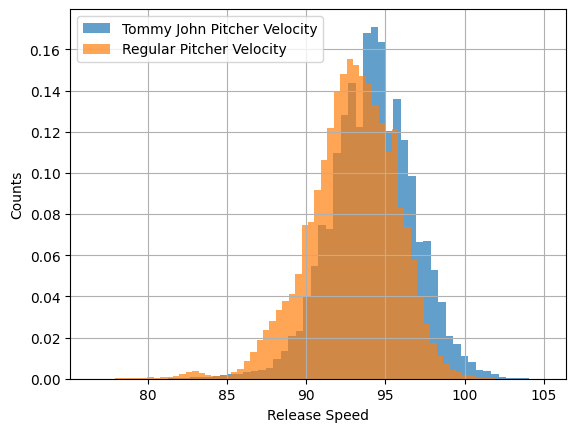

In [46]:
plt.plot()
Injured_Fastball_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Tommy John Pitcher Velocity', density = True)
Healthy_Fastball_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Regular Pitcher Velocity', density = True)
plt.xlabel("Release Speed")
plt.ylabel("Counts")
plt.legend()
plt.savefig('.data/plots/Fastball_Release_Speed_Hist.png', dpi = 400)
plt.show()

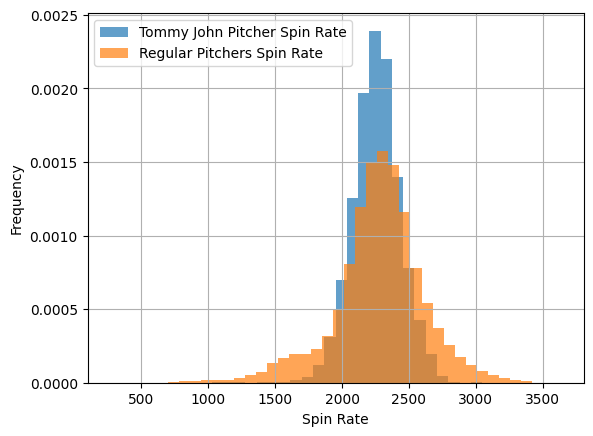

In [47]:
plt.plot()
Injured_Fastball_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Tommy John Pitcher Spin Rate', density = True)
Healthy_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Regular Pitchers Spin Rate', density = True)
plt.xlabel("Spin Rate")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/fastball_release_spin_rate_hist.png', dpi = 400)
plt.show()

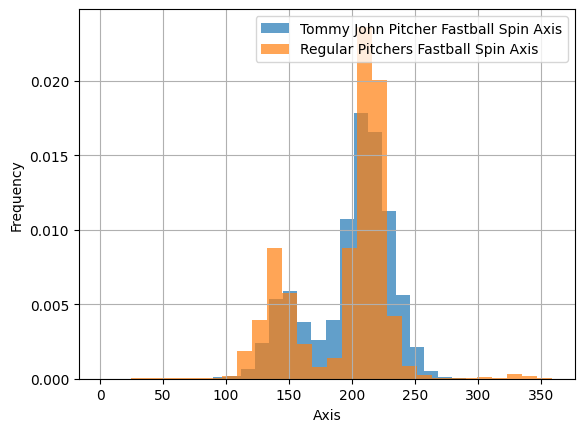

In [48]:
plt.plot()
Injured_Fastball_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Tommy John Pitcher Fastball Spin Axis', density = True)
Healthy_Fastball_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Regular Pitchers Fastball Spin Axis', density = True)
plt.xlabel("Axis")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/fastball_spin_axis_hist.png', dpi = 400)
plt.show()

In [49]:
# Creating Four seam Fastball Dataframes
healthy_FF_data = []
for key in healthy.keys():
  x = healthy[key][8]
  y = []
  for i in x.values:
    y.append(0)
  z = x.assign(TJ = y)
  healthy_FF_data.append(z)

injured_FF_data = []
for key in injured.keys():
  x = injured[key][8]
  y = []
  for i in x.values:
    y.append(1)
  z = x.assign(TJ = y)
  injured_FF_data.append(z)
Healthy_FF_df = pd.concat(healthy_FF_data)
Injured_FF_df = pd.concat(injured_FF_data)

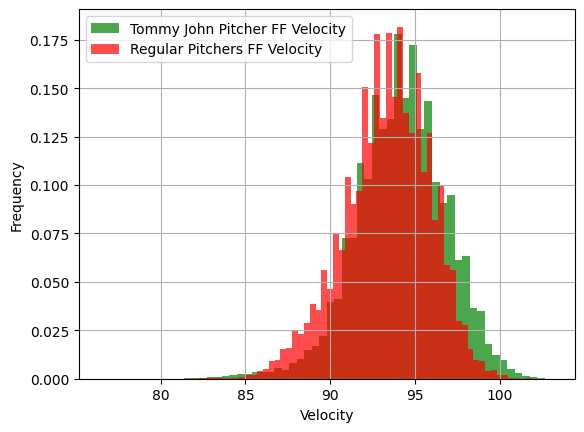

In [50]:
# plot to see release speed
plt.plot()
Injured_FF_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Tommy John Pitcher FF Velocity', color = 'Green', density = True)
Healthy_FF_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Regular Pitchers FF Velocity', color = 'Red', density = True)
plt.xlabel("Velocity")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/FF_Release_Speed_Hist.png', dpi = 400)
plt.show()

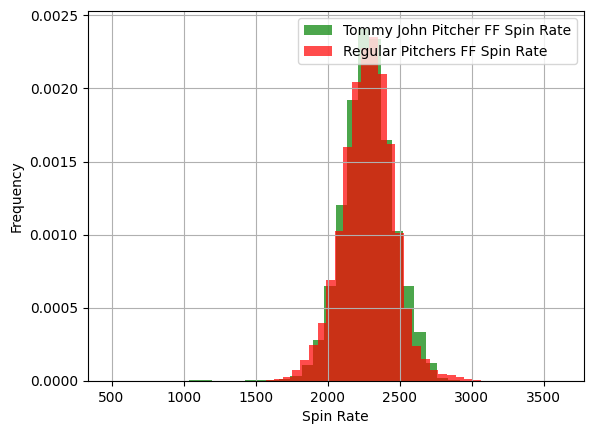

In [51]:
# plot to see Fastball spin rate
plt.plot()
Injured_FF_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Tommy John Pitcher FF Spin Rate', color = 'Green', density = True)
Healthy_FF_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Regular Pitchers FF Spin Rate', color = 'Red', density = True)
plt.xlabel("Spin Rate")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/FF_Release_Spin_Rate_Hist.png', dpi = 400)
plt.show()

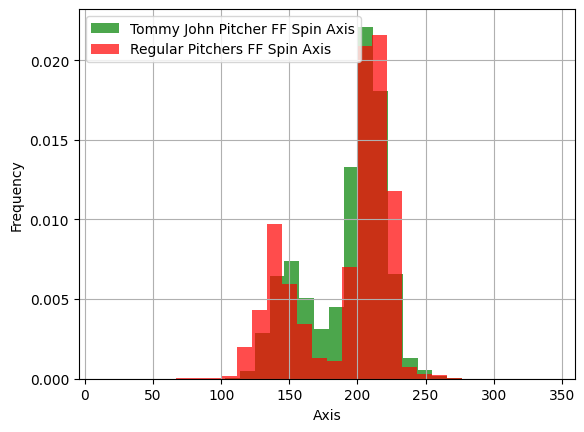

In [52]:
# plot to see Four Seam spin axis
plt.plot()
Injured_FF_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Tommy John Pitcher FF Spin Axis', color = 'Green', density = True)
Healthy_FF_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Regular Pitchers FF Spin Axis', color = 'Red', density = True)
plt.xlabel("Axis")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/FF_Spin_Axis_Hist.png', dpi = 400)
plt.show()

In [53]:
# creating dataframes of only sinkers
healthy_SI_data = []
for key in healthy.keys():
  x = healthy[key][9]
  y = []
  for i in x.values:
    y.append(0)
  z = x.assign(TJ = y)
  healthy_SI_data.append(z)
injured_SI_data = []
for key in injured.keys():
  x = injured[key][9]
  y = []
  for i in x.values:
    y.append(1)
  z = x.assign(TJ = y)
  injured_SI_data.append(z)

Healthy_SI_df = pd.concat(healthy_SI_data)
Injured_SI_df = pd.concat(injured_SI_data)

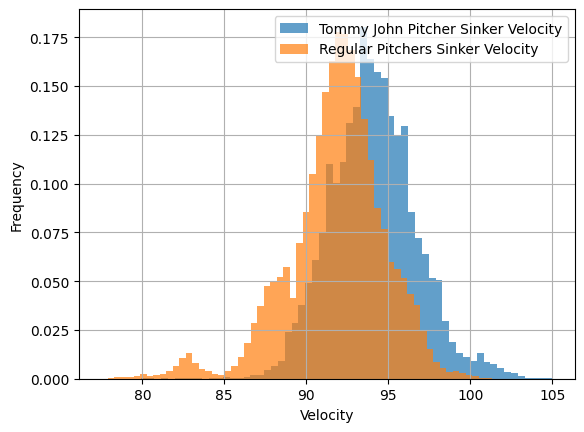

In [54]:
plt.plot()
Injured_SI_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Tommy John Pitcher Sinker Velocity', density = True)
Healthy_SI_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Regular Pitchers Sinker Velocity', density  = True)
plt.xlabel("Velocity")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/SI_Release_Speed_Hist.png', dpi = 400)
plt.show()

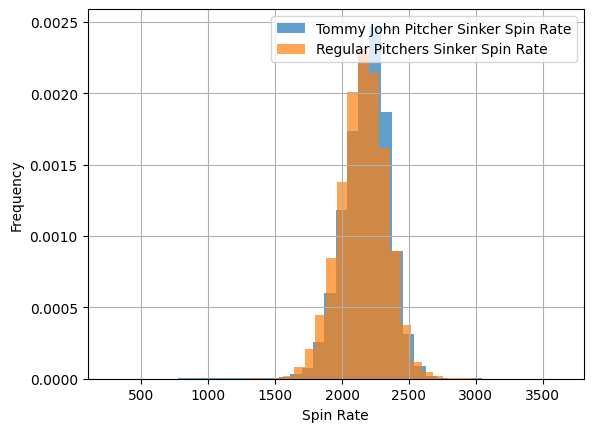

In [55]:
plt.plot()
Injured_SI_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Tommy John Pitcher Sinker Spin Rate', density = True)
Healthy_SI_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Regular Pitchers Sinker Spin Rate', density = True)
plt.xlabel("Spin Rate")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/SI_Release_Spin_Rate_Hist.png', dpi = 400)
plt.show()

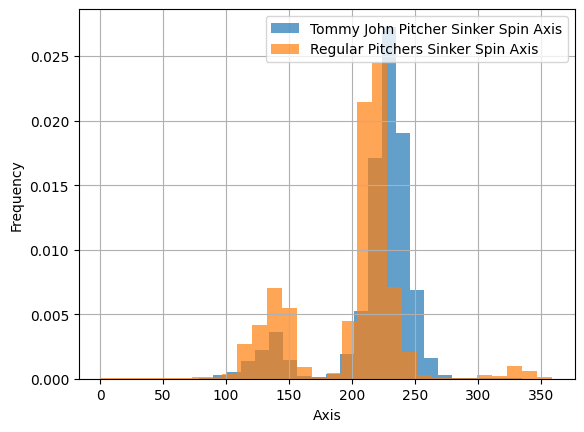

In [56]:
plt.plot()
Injured_SI_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Tommy John Pitcher Sinker Spin Axis', density = True)
Healthy_SI_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Regular Pitchers Sinker Spin Axis', density = True)
plt.xlabel("Axis")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/SI_Spin_Axis_Hist.png', dpi = 400)
plt.show()

In [58]:
# Dataframe of only cutters
healthy_FC_data = []
for key in healthy.keys():
  x = healthy[key][10]
  y = []
  for i in x.values:
    y.append(0)
  z = x.assign(TJ = y)
  healthy_FC_data.append(z)
injured_FC_data = []
for key in injured.keys():
  x = injured[key][10]
  y = []
  for i in x.values:
    y.append(1)
  z = x.assign(TJ = y)
  injured_FC_data.append(z)

Healthy_FC_df = pd.concat(healthy_FC_data)
Injured_FC_df = pd.concat(injured_FC_data)

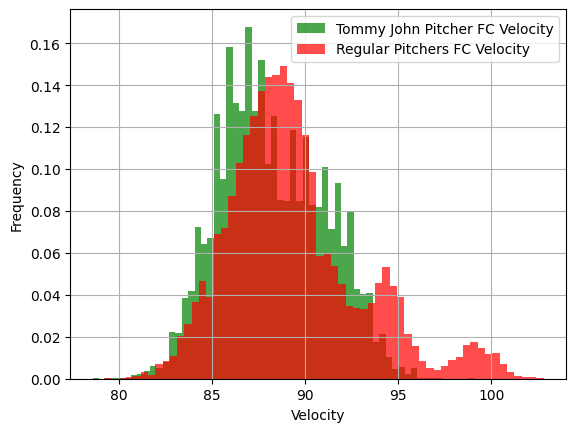

In [59]:
plt.plot()
Injured_FC_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Tommy John Pitcher FC Velocity', color = 'Green', density = True)
Healthy_FC_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Regular Pitchers FC Velocity', color = 'Red', density = True)
plt.xlabel("Velocity")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/FC_Release_Speed_Hist.png', dpi = 400)
plt.show()

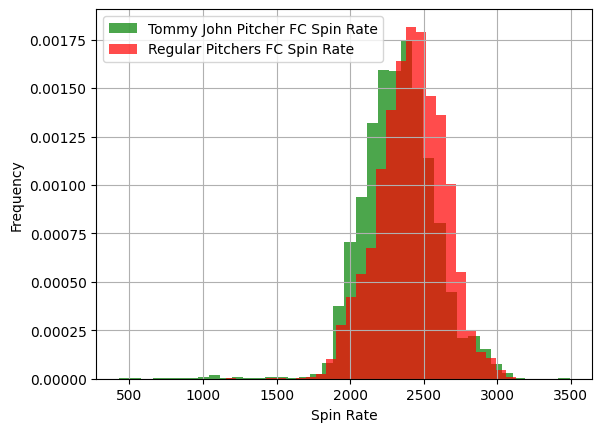

In [61]:
plt.plot()
Injured_FC_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Tommy John Pitcher FC Spin Rate', color = 'Green', density = True)
Healthy_FC_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Regular Pitchers FC Spin Rate', color = 'Red', density = True)
plt.xlabel("Spin Rate")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/FC_Release_Spin_Rate_Hist.png', dpi = 400)
plt.show()

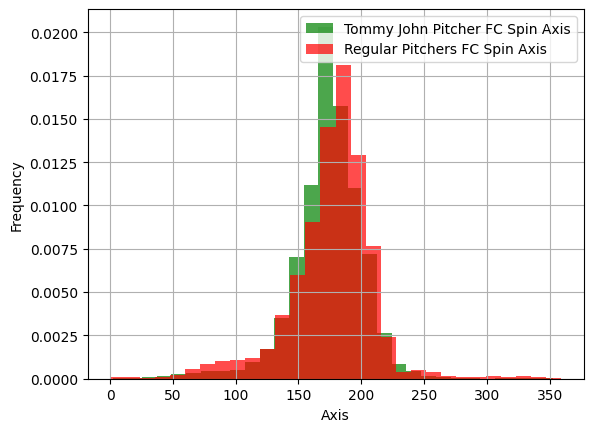

In [60]:
plt.plot()
Injured_FC_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Tommy John Pitcher FC Spin Axis', color = 'Green', density = True)
Healthy_FC_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Regular Pitchers FC Spin Axis', color = 'Red', density = True)
plt.xlabel("Axis")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/FC_Spin_Axis_Hist.png', dpi = 400)
plt.show()

In [62]:
# Creating Changeup Data Sets
healthy_CH_data = []
for key in healthy.keys():
  x = healthy[key][11]
  y = []
  for i in x.values:
    y.append(0)
  z = x.assign(TJ = y)
  healthy_CH_data.append(z)
injured_CH_data = []
for key in injured.keys():
  x = injured[key][11]
  y = []
  for i in x.values:
    y.append(1)
  z = x.assign(TJ = y)
  injured_CH_data.append(z)

Healthy_CH_df = pd.concat(healthy_CH_data)
Injured_CH_df = pd.concat(injured_CH_data)

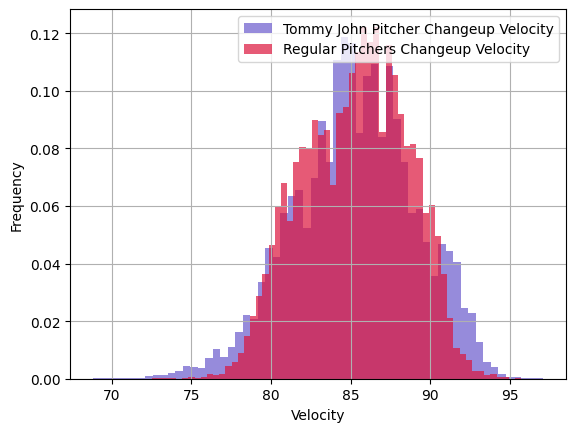

In [64]:
# plot to see changeup velocity
plt.plot()
Injured_CH_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Tommy John Pitcher Changeup Velocity', color = 'slateblue', density = True)
Healthy_CH_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Regular Pitchers Changeup Velocity', color = 'crimson', density = True)
plt.xlabel("Velocity")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/CH_Release_Speed_Hist.png', dpi = 400)
plt.show()

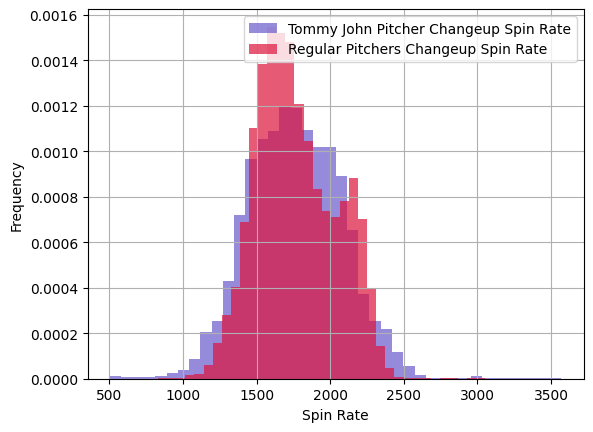

In [66]:
# plot to see Changeup Spin Rate 
plt.plot()
Injured_CH_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Tommy John Pitcher Changeup Spin Rate', color = 'slateblue', density = True)
Healthy_CH_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Regular Pitchers Changeup Spin Rate', color = 'crimson', density = True)
plt.xlabel("Spin Rate")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/CH_Release_Spin_Rate_Hist.png', dpi = 400)
plt.show()

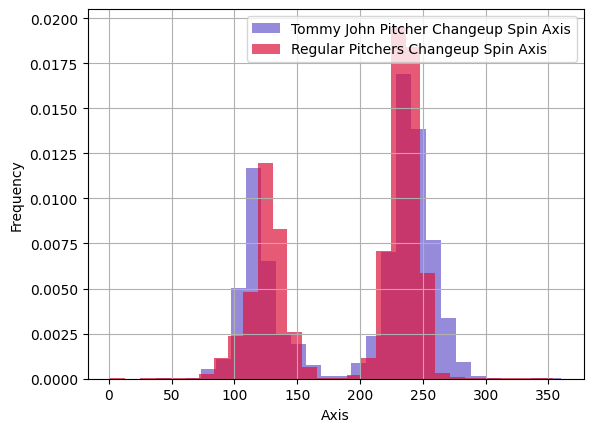

In [67]:
# plot to see Changeup Spin Axis
plt.plot()
Injured_CH_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Tommy John Pitcher Changeup Spin Axis', color = 'slateblue', density = True)
Healthy_CH_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Regular Pitchers Changeup Spin Axis', color = 'crimson', density = True)
plt.xlabel("Axis")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/CH_Spin_Axis_Hist.png', dpi = 400)
plt.show()

In [68]:
# Creating Splitter datasets
healthy_SPL_data = []
for key in healthy.keys():
  x = healthy[key][12]
  y = []
  for i in x.values:
    y.append(0)
  z = x.assign(TJ = y)
  healthy_SPL_data.append(z)
injured_SPL_data = []
for key in injured.keys():
  x = injured[key][12]
  y = []
  for i in x.values:
    y.append(1)
  z = x.assign(TJ = y)
  injured_SPL_data.append(z)

Healthy_SPL_df = pd.concat(healthy_SPL_data)
Injured_SPL_df = pd.concat(injured_SPL_data)

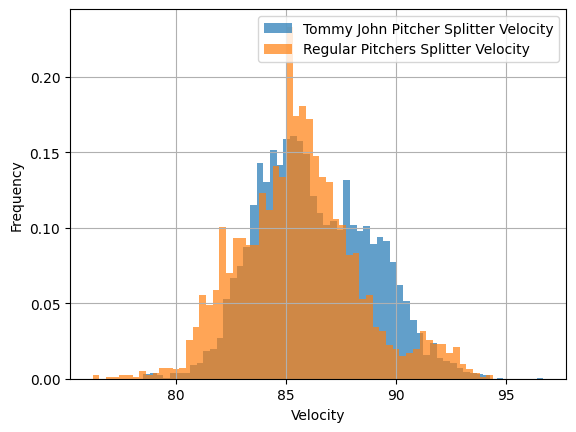

In [69]:
# plot to see splitter velocity
plt.plot()
Injured_SPL_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Tommy John Pitcher Splitter Velocity', density = True)
Healthy_SPL_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Regular Pitchers Splitter Velocity', density = True)
plt.xlabel("Velocity")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/SPL_Release_Speed_Hist.png', dpi = 400)
plt.show()

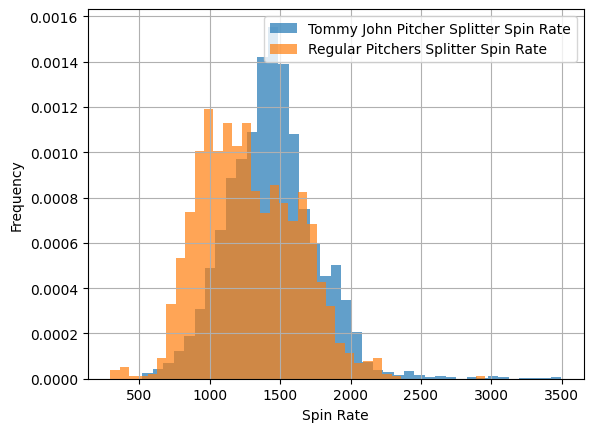

In [70]:
# plot to see Splitter spin rate
plt.plot()
Injured_SPL_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Tommy John Pitcher Splitter Spin Rate', density = True)
Healthy_SPL_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Regular Pitchers Splitter Spin Rate', density = True)
plt.xlabel("Spin Rate")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/SPL_Release_Spin_Rate_Hist.png', dpi = 400)
plt.show()

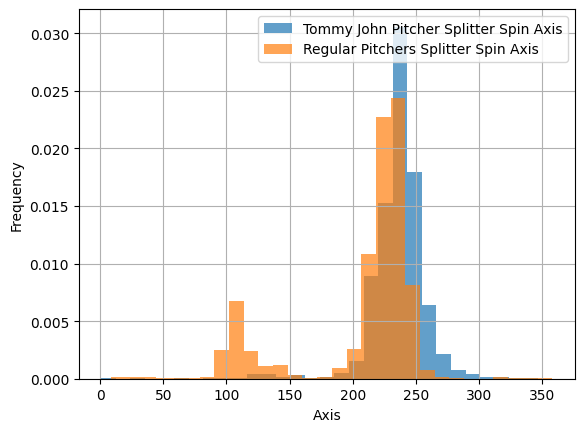

In [71]:
# plot to see splitter spin axis
plt.plot()
Injured_SPL_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Tommy John Pitcher Splitter Spin Axis', density = True)
Healthy_SPL_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Regular Pitchers Splitter Spin Axis', density = True)
plt.xlabel("Axis")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/SPL_Spin_Axis_Hist.png', dpi = 400)
plt.show()

In [72]:
# creating slider dataframes
healthy_slider_data = []
for key in healthy.keys():
  x = healthy[key][13]
  y = []
  for i in x.values:
    y.append(0)
  z = x.assign(TJ = y)
  healthy_slider_data.append(z)

injured_slider_data = []
for key in injured.keys():
  x = injured[key][13]
  y = []
  for i in x.values:
    y.append(1)
  z = x.assign(TJ = y)
  injured_slider_data.append(z)
Healthy_slider_df = pd.concat(healthy_slider_data)
Injured_slider_df = pd.concat(injured_slider_data)

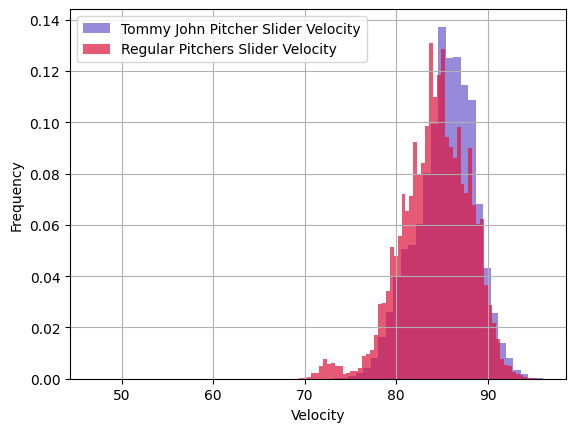

In [73]:
plt.plot()
Injured_slider_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Tommy John Pitcher Slider Velocity', color = 'slateblue', density = True)
Healthy_slider_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Regular Pitchers Slider Velocity', color = 'crimson', density = True)
plt.xlabel("Velocity")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/SL_Release_Speed_Hist.png', dpi = 400)
plt.show()

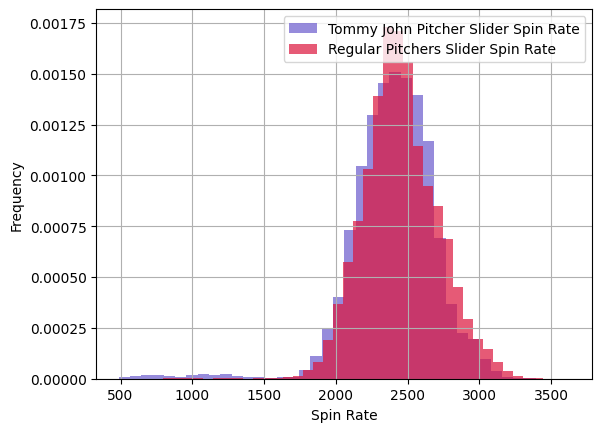

In [74]:
plt.plot()
Injured_slider_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Tommy John Pitcher Slider Spin Rate', color = 'slateblue', density = True)
Healthy_slider_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Regular Pitchers Slider Spin Rate', color = 'crimson', density = True)
plt.xlabel("Spin Rate")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/SL_Release_Spin_Rate_Hist.png', dpi = 400)
plt.show()

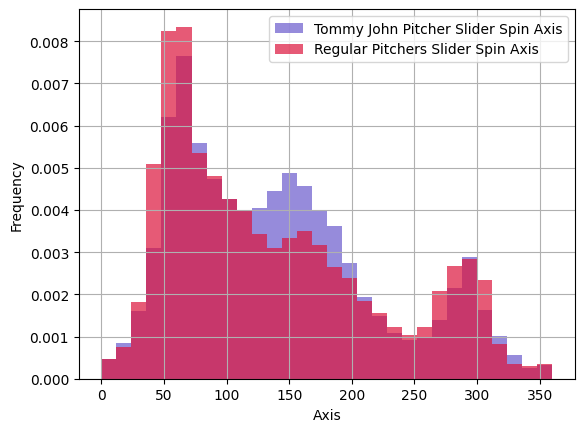

In [75]:
plt.plot()
Injured_slider_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Tommy John Pitcher Slider Spin Axis', color = 'slateblue', density  = True)
Healthy_slider_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Regular Pitchers Slider Spin Axis', color = 'crimson', density = True)
plt.xlabel("Axis")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/SL_Spin_Axis_Hist.png', dpi = 400)
plt.show()

In [76]:
# creating sweeper dataframes
healthy_SWP_data = []
for key in healthy.keys():
  x = healthy[key][14]
  y = []
  for i in x.values:
    y.append(0)
  z = x.assign(TJ = y)
  healthy_SWP_data.append(z)
injured_SWP_data = []
for key in injured.keys():
  x = injured[key][14]
  y = []
  for i in x.values:
    y.append(1)
  z = x.assign(TJ = y)
  injured_SWP_data.append(z)

Healthy_SWP_df = pd.concat(healthy_SWP_data)
Injured_SWP_df = pd.concat(injured_SWP_data)

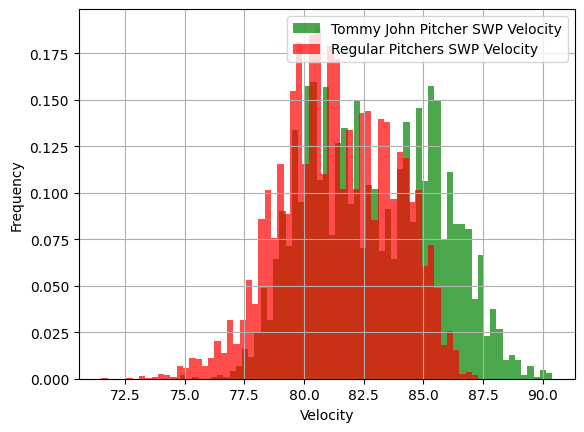

In [77]:
# plot to see sweeper velocity
plt.plot()
Injured_SWP_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Tommy John Pitcher SWP Velocity', color = 'Green', density = True)
Healthy_SWP_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Regular Pitchers SWP Velocity', color = 'Red', density = True)
plt.xlabel("Velocity")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/SWP_Release_Speed_Hist.png', dpi = 400)
plt.show()

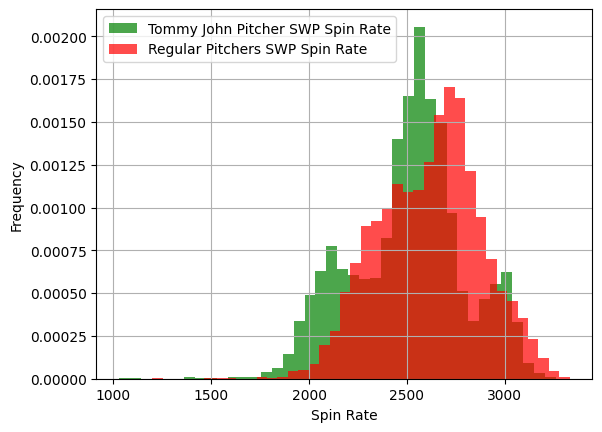

In [78]:
# sweeper spin rate
plt.plot()
Injured_SWP_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Tommy John Pitcher SWP Spin Rate', color = 'Green', density = True)
Healthy_SWP_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Regular Pitchers SWP Spin Rate', color = 'Red', density = True)
plt.xlabel("Spin Rate")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/SWP_Release_Spin_Rate_Hist.png', dpi = 400)
plt.show()

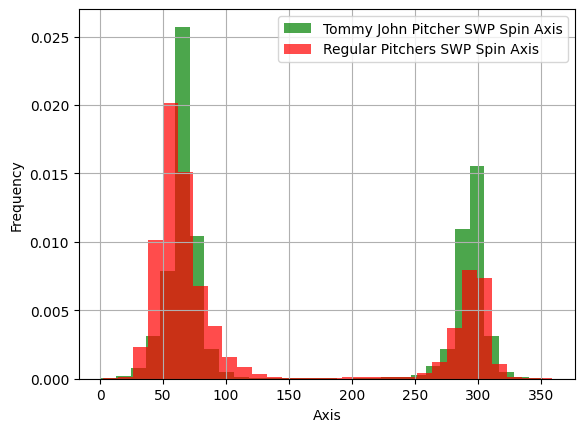

In [79]:
# plot to sweeper spin axis
plt.plot()
Injured_SWP_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Tommy John Pitcher SWP Spin Axis', color = 'Green', density = True)
Healthy_SWP_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Regular Pitchers SWP Spin Axis', color = 'Red', density = True)
plt.xlabel("Axis")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/SWP_Spin_Axis_Hist.png', dpi = 400)
plt.show()

In [80]:
# creating curveball dataframes
healthy_CU_data = []
for key in healthy.keys():
  x = healthy[key][15]
  y = []
  for i in x.values:
    y.append(0)
  z = x.assign(TJ = y)
  healthy_CU_data.append(z)
injured_CU_data = []
for key in injured.keys():
  x = injured[key][15]
  y = []
  for i in x.values:
    y.append(1)
  z = x.assign(TJ = y)
  injured_CU_data.append(z)

Healthy_CU_df = pd.concat(healthy_CU_data)
Injured_CU_df = pd.concat(injured_CU_data)

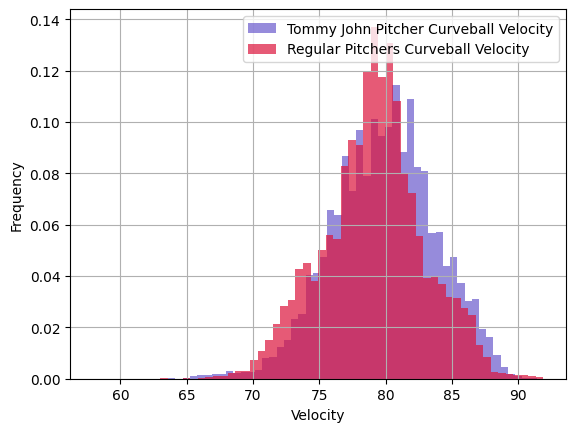

In [81]:
# plot to see curveball velocity
plt.plot()
Injured_CU_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Tommy John Pitcher Curveball Velocity', color = 'slateblue', density = True)
Healthy_CU_df['release_speed'].hist(bins = 60, alpha = 0.7, label = 'Regular Pitchers Curveball Velocity', color = 'crimson', density = True)
plt.xlabel("Velocity")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/CU_Release_Speed_Hist.png', dpi = 400)
plt.show()

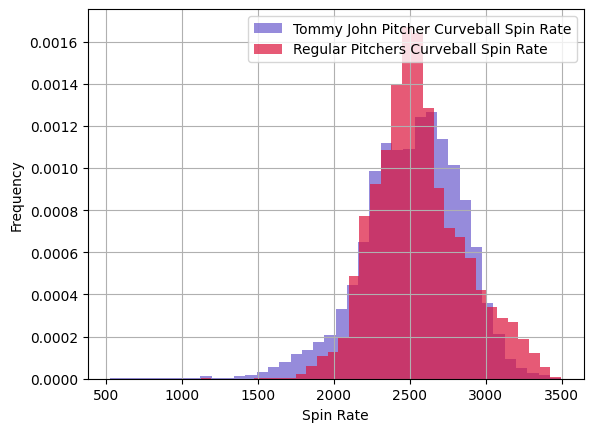

In [82]:
# plot to see curveball spin rate
plt.plot()
Injured_CU_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Tommy John Pitcher Curveball Spin Rate', color = 'slateblue', density = True)
Healthy_CU_df['release_spin_rate'].hist(bins = 40, alpha = 0.7, label = 'Regular Pitchers Curveball Spin Rate', color = 'crimson', density = True)
plt.xlabel("Spin Rate")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('.data/plots/CU_Release_Spin_Rate_Hist.png', dpi = 400)
plt.show()

In [ ]:
# Curveball spin axis
plt.plot()
Injured_CU_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Tommy John Pitcher Curveball Spin Axis', color = 'slateblue', density = True)
Healthy_CU_df['spin_axis'].hist(bins = 30, alpha = 0.7, label = 'Regular Pitchers Curveball Spin Axis', color = 'crimson', density = True)
plt.xlabel("Axis")
plt.ylabel("Frequency")
plt.legend()

plt.show()